# _Anuario de Aforos_: selection of stations
***

***Author:** Chus Casado Rodríguez*<br>
***Date:** 10-04-2026*<br>

**Introducción:**<br>

This notebook analyses the data in the _Anuario de Aforos de España_ regarding gauging stations and streamflow.It does a pre-selection of stations to be included in CAMELS-ES based on:

* Minimum data availability in the streamflow series.
* Minimum catchment area

The selection is defined in the YAML configuration file.

**Outputs:**<br>
* A point GeoJSON file of the pre-selected stations.
* A CSV file required to delineate the basins of the pre-selected stations.

**To do**:<br>


In [ ]:
import os
import pandas as pd
# import geopandas as gpd
# import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from pathlib import Path

from ocab.config import Config
from ocab.anuario.stations.stations import get_gauges_basin, get_gauges_miteco
from ocab.anuario.timeseries import get_river_series, manage_conflicts, select_study_period
from ocab.plots import plot_stations, plot_discharge, create_station_html#, create_index
from ocab.basins.delineate.utils import create_input_file

In [2]:
import unicodedata
import re

def slugify(value):
    # Remove accents
    value = unicodedata.normalize('NFKD', value).encode('ascii', 'ignore').decode('ascii')
    # Remove non-alphanumeric characters and replace spaces with hyphens
    value = re.sub(r'[^\w\s-]', '', value).strip().lower()
    return re.sub(r'[-\s]+', '-', value)

## Configuration

In [3]:
cfg = Config('config_CAMELS_v120.yml')

# overlaping stations and action to take
conflicts = {
    (4207, 4208): 'remove 4208',
    (2095, 2530): 'combine',
    (1607, 1608): 'remove 1608',
    (7055, 7171, 7172): 'keep 7055'
}

## Gauging stations



### Anuario de Aforos

No. stations in   Cantabrico:	  94
No. stations in        Duero:	 209
No. stations in         Ebro:	 279
No. stations in Galicia costa:	  49
No. stations in Guadalquivir:	 113
No. stations in     Guadiana:	 145
No. stations in        Jucar:	 109
No. stations in     Miño-sil:	  86
No. stations in       Segura:	  82
No. stations in         Tajo:	 203

Total no. stations:		1369
Total no. active stations:	 902


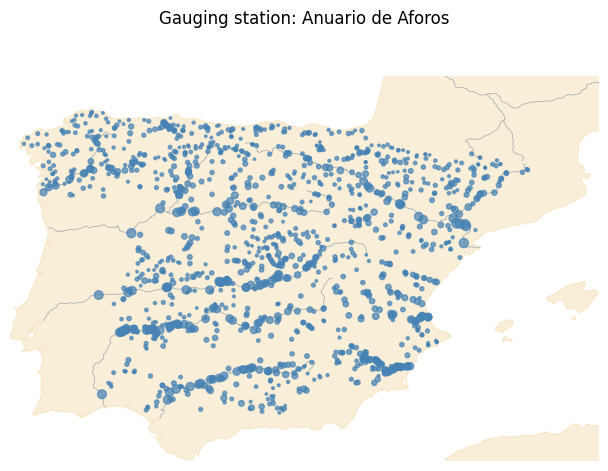

In [4]:
# identificar demarcaciones hidrográficas
basins = {
    dir.stem: dir for dir in sorted(cfg.path_records.iterdir()) 
    if dir.is_dir() &  (dir.stem not in ['estaciones', 'GIS', 'timeseries'])
    }

# extraer estaciones del Anuario de Aforos
stations = []
for basin, folder in basins.items():
    stns = get_gauges_basin(
        folder,
        min_area=cfg.area_min, 
        max_area=cfg.area_max, 
        years=cfg.min_years, 
        epsg=cfg.crs
        )
    stns['basin'] = basin
    stations.append(stns)
    print('No. stations in {0:>12}:\t{1:>4}'.format(basin.capitalize(), stns.shape[0]))
stations = pd.concat(stations, axis=0)
stations.sort_index(axis=0, inplace=True)

# mapa de las estaciones
plot_stations(
    stations.geometry, 
    area=stations.catch_skm, 
    extent=[-9.5, 3.5, 36, 44.5],
    title=f'Gauging station: Anuario de Aforos',
    # save=cfg.path_plots / 'stations.jpg'
)

print('\nTotal no. stations:\t\t{0:>4}'.format(stations.shape[0]))
print('Total no. active stations:\t{0:>4}'.format(stations.loc[stations.active == 1].shape[0]))

### MITECO

In [5]:
# load stations from MITECO
stations_miteco = get_gauges_miteco(
    cfg.path_records / 'estaciones' / 'Situac_4_Rio_rev.csv',
    # active=False,
    # min_area=cfg.area_min
)
print('No. stations in MITECO:\t\t{0:>4}'.format(stations_miteco.shape[0]))

missing_ids =stations.index.difference(stations_miteco.index)
print('No. stations missing in Miteco:\t{0:>4}'.format(len(missing_ids)))

# update missing values from those in MITECO
for col in stations.columns.intersection(stations_miteco.columns):
    stations[col] = stations[col].combine_first(stations_miteco[col])
    
# add new columns from MITECO
for col in stations_miteco.columns.difference(stations.columns):
    stations[col] = stations_miteco[col]

# sort columns
cols = sorted([col for col in stations.columns if col != 'geometry']) + ['geometry']
stations = stations[cols]

No. stations in MITECO:		1491
No. stations missing in Miteco:	   0


## Discharge Time Series

In [ ]:
# extract time series from "Anuario de Aforos"
timeseries = {}
for basin, path in tqdm(basins.items(), desc='basins'):
    ids = stations[stations.basin == basin].index.to_list()
    data = get_river_series(
        path,
        ids, 
        start=cfg.start,
        end=cfg.end,
    )
    
    # check for conflicts
    data = manage_conflicts(data, conflicts)

    print('No. stations in {0:<14}\t\t\t{1:>4} ({2:>4})'.format(basin.title() + ':', len(data), len(ids)))
    timeseries.update(data)

print('\nTotal no. sations with time series:\t{0:>4} ({1:>4})'.format(len(timeseries), len(stations)))

basins:   0%|          | 0/10 [00:00<?, ?it/s]

No. stations in Cantabrico:  			  78 (  94)
No. stations in Duero:       			 195 ( 209)
No. stations in Ebro:        			 253 ( 279)
No. stations in Galicia Costa:			  44 (  49)
No. stations in Guadalquivir:			  91 ( 113)
No. stations in Guadiana:    			 101 ( 145)
No. stations in Jucar:       			  54 ( 109)
No. stations in Miño-Sil:    			  67 (  86)
No. stations in Segura:      			  50 (  82)
No. stations in Tajo:        			 136 ( 203)

Total no. sations with discharge time series:	1069 (1369)


### Select Stations and Study Period

In [7]:
# add boolean fields with available variables
vars = ['discharge']
stations[vars ] = 0
for ID, ts in timeseries.items():
    stations.loc[ID, vars ] = [int(var in ts.columns) for var in vars]
mask_vars = stations[vars].any(axis=1)
print('No. stations with daily time series:\t\t\t{0:>4}'.format(mask_vars.sum()))

# pre-select best period of data
periods = pd.concat([
    select_study_period(
        ts[ts.columns.intersection(vars)], 
        ID,
        cfg.availability, 
        cfg.min_years, 
        mode='any'
    ) for ID, ts in timeseries.items()
], axis=0)
stations.loc[periods.index, ['start', 'end']] = periods.values

# compute no. years with daily time series
stations['years_daily'] = (stations.end - stations.start).astype('Int64')
mask_years = stations.years_daily >= cfg.min_years
print('No. stations with at least {0} years of daily data:\t{1:>4}'.format(cfg.min_years, mask_years.sum()))

# select stations
mask_stns = mask_years & mask_vars
print('No. selected stations:\t\t\t\t\t{0:>4}'.format(mask_stns.sum()))

No. stations with daily time series:			1046
No. stations with at least 4 years of daily data:	1152
No. selected stations:					 891


## Export



### Stations

In [19]:
# export shapefile
file_stations = cfg.path_gis / 'stations.geojson'
stations[mask_stns].to_file(file_stations, driver='GeoJSON')

#### `basin-delineation`

This section creates the GeoJSON file required as input to locate the stations in the MERIT and EFAS grids.

In [21]:
path = cfg.path_dataset / 'preprocessing' / 'basins'
path.mkdir(parents=True, exist_ok=True)
create_input_file(
    geometry=stations.loc[mask_stns, 'geometry'],
    area=stations.loc[mask_stns, 'catch_skm'],
    file=path / 'stations.geojson'
)

### Discharge time series

In [22]:
# exportar las series de caudal
path_ts = cfg.path_dataset / 'preprocessing' / 'timeseries' / 'discharge'
path_ts.mkdir(parents=True, exist_ok=True)
for ID in tqdm(stations[mask_stns].index, desc='stations'):
    ts = timeseries[ID][['discharge']]
    start, end = ts.first_valid_index(), ts.last_valid_index()
    # start, end = stations.loc[ID, ['inicio', 'fin']]
    ts.loc[start:end].to_parquet(path_ts / f'{ID}.parquet')

stations:   0%|          | 0/891 [00:00<?, ?it/s]

### Hidrogramas

In [ ]:
regimenes = {
    'desconocido': 'dimgrey',
    'natural': 'steelblue',
    'alterado': 'indianred',
    'regulado': 'gold',
}

estaciones_sel = []
index_glob = []
stations['url_link'] = ''
path_ghpages = Path(os.getcwd()).parent.parent / 'docs'
url_ghpages = 'https://casadoj.github.io/CAMELS-ES'
for basin in tqdm(basins, desc='Cuencas'):

    # crear estructura de archivos
    cuenca_str = slugify(basin)
    path_basin = path_ghpages / cuenca_str
    index_glob.append((f'./{cuenca_str}/index.html', basin.capitalize()))
    index_basin = []

    # filtrar estaciones en la cuenca con datos de caudal
    stns_basin = stations.loc[(stations.basin == basin) & (stations.discharge == 1) & mask_years]

    # iterar por sistemas de explotación
    sistemas = list(set(stns_basin.sistema))
    pbar_sys = tqdm(sorted(sistemas), total=len(sistemas), desc='Sistema', leave=False)
    for sistema in pbar_sys:
        # índice y ruta del sistema
        sistema_str = slugify(sistema)
        path_sys = path_basin / sistema_str
        path_plots = path_sys / 'plots'
        path_plots.mkdir(parents=True, exist_ok=True)
        index_sys = []

        # actualizar índice de la demarcación
        index_basin.append((f'./{sistema_str}/index.html', sistema.capitalize()))
        
        # crear los hidrogramas
        stns = stns_basin.loc[stns_basin.sistema == sistema]
        stns.sort_index(inplace=True)
        pbar = tqdm(enumerate(stns.iterrows()), total=len(stns), desc='Estaciones', leave=False)
        for i, (id, attrs) in pbar:
            if id not in discharge.columns:
                continue

            # crear el hidrograma en HTML
            ts = discharge[id]
            ts = ts.loc[ts.first_valid_index():ts.last_valid_index()]
            title = '{0} - {1} - River {2} ({3})'.format(id, attrs.lugar.title(), attrs.rio.title(), basin.title())
            file = f'./plots/{id}.html'
            fig = plot_discharge(
                ts,
                area=attrs.suprest,
                title=title,
                regime=attrs.regimen,
                c=regimenes[attrs.regimen],
                save=True
            )
            create_station_html(
                fig, 
                path=path_sys / file, 
                start=ts.index.min().strftime('%Y-%m-%d'), 
                end=ts.index.max().strftime('%Y-%m-%d')
            )
            # create_station_html(
            #     ts, 
            #     area=attrs.suprest,
            #     title=title,
            #     regime=attrs.regimen,
            #     c=regimenes[attrs.regimen],
            #     save=path_sys / file,
            # )

            # guardar el archivo en el índice y el GeoDataFrame
            index_sys.append((file, title))
            stns_basin.loc[id, 'url_link'] = f'{url_ghpages}/{basin.title()}/{sistema.title()}/plots/{id}.html'

        # crear índice del sistema de explotación
        # create_index(
        #     path_sys, 
        #     title=sistema.lower(), 
        #     header=sistema.title(), 
        #     index=index_sys,
        #     target='_self',
        #     parent='Sistemas'
        #     )

    # crear índice de la cuenca
    # create_index(
    #     path_basin, 
    #     title=cuenca.lower(), 
    #     header=cuenca.title(), 
    #     index=index_basin, 
    #     target='_self',
    #     parent='Cuencas')

    estaciones_sel.append(stns_basin)

In [ ]:
# guardar shapefile
if isinstance(estaciones_sel, list):
    estaciones_sel = pd.concat(estaciones_sel, axis=0)
    for col in ['rio', 'sistema', 'basin']:
        stations[col] = stations[col].str.title()
# estaciones_sel.to_file(cfg.path_GIS / f'estaciones_caudal.shp')
estaciones_sel.to_file(path_ghpages / "estaciones.geojson", driver='GeoJSON')

# # crear índice global
# create_index(path_ghpages, title='camels-es', header='Cuencas', index=index_glob, target='_self')

## Selección de estaciones

***

In [ ]:
# estaciones a eliminar porque la serie está alterada por embalses
# las estaciones comentadas son etaciones dudosas
eliminar = {'CANTABRICO': ['1164','1175', '1186', '1196', '1207', '1215', '1237',
                           '1264', '1274', '1276', '1294', '1335', '1358', '1359',
                           '1425', '1446', '1588', '1805'],
            'DUERO': ['2001', '2002', '2004', '2010', '2011', '2018', '2019', '2020',
                      '2021', '2023', '2024', '2032', '2040', '2042', '2044', '2048', '2052', '2066',
                      '2073', '2075', '2078', '2084', '2087', '2088', '2091', '2094',
                      '2099', '2102', '2103', '2108', '2109', '2111', '2112', '2124', '2129',
                      '2133', '2134', '2135', '2137', '2140', '2148', '2149', '2161',
                      '2162', '2718', '2719'],
            #'2041', '2050', '2061', '2062', '2074'
            'EBRO': ['9001', '9005', '9007', '9008', '9010', '9012', '9013', '9014',
                     '9015', '9017', '9022', '9024', '9025', '9026', '9027', '9031',
                     '9032', '9034', '9035', '9036', '9042', '9047', '9048', '9049',
                     '9055', '9056', '9057', '9058', '9059', '9060', '9065', '9066', '9076', '9083',
                     '9084', '9087', '9094', '9096', '9097', '9099', '9100', '9101', '9105',
                     '9106', '9111', '9115', '9118', '9122', '9123', '9124', '9125',
                     '9126', '9127', '9137', '9142', '9145', '9147', '9155', '9161',
                     '9163', '9168', '9174', '9176', '9185', '9186', '9190', '9191', '9192',
                     '9193', '9201', '9209', '9216', '9225', '9229', '9230', '9231', '9250', '9250',
                     '9251', '9255', '9258', '9260', '9264', '9266', '9273', '9277', '9278', '9290',
                     '9292', '9307', '9315', '9319'],
            #, '9153', '9291', '9317'
            'GALICIA': ['1455', '1514', '1519', '1550', '1564'],
            'GUADALQUIVIR': ['5001', '5004', '5014', '5019', '5020', '5024', '5025',
                             '5027', '5041', '5042', '5048', '5077', '5081', '5082', '5084', '5090',
                             '5095', '5127', '5140', '5147', '5144', '5150'],
             # '5045', '5050', '5138', '5140', ''
            'GUADIANA': ['4004', '4009', '4013', '4030', '4105', '4201', '4202', '4203', '4207', '4209',
                         '4212', '4214', '4904'],
            # , ''
            'JUCAR': ['8005', '8015', '8022', '8025', '8027', '8032', '8036', '8042', '8071', '8074', '8089',
                      '8092', '8093', '8096', '8107', '8112', '8119', '8129', '8130', '8137', '8138', '8139',
                      '8140', '8144', '8145', '8147', '8148', '8153'],
                      #, '8028', '8032', '8060', '8104', '8120'
            'MINHO': ['1631', '1639', '1640', '1642', '1719', '1831'],
            'SEGURA': ['7001', '7003', '7004', '7006', '7013', '7016', '7018', '7029', '7030', '7055',
                       '7057', '7062', '7063', '7064', '7112', '7121', '7124', '7137', '7164', '7167', '7628'],
            # , '7112', '7117', '7121', '7165', ''
            'TAJO': ['3003', '3031', '3041', '3048', '3054', '3060', '3061', '3063', '3067', '3070', '3080',
                     '3082', '3147', '3149', '3153', '3158', '3162', '3164', '3172', '3173', '3177', '3183',
                     '3187', '3188', '3230', '3232', '3233', '3237', '3238', '3240', '3243', '3248',
                     '3251', '3254', '3255', '3258', '3259', '3270', '3271', '3273', '3281', '3904',
                      '3940'],
            #'3012', '3014', '3062, '3169', '3174', '3175', '3220', '3233', 
            #'3250', '3251', '3253', '3255', '3256', '3268', '3276', '3278', '3279', ''
            }

In [ ]:
# crear campo booleano con las estaciones seleccionadas
stations['sel'] = (~stations.inicio.isnull()).astype(int)
for basin in basins:
    stations.loc[eliminar[basin], 'sel'] = 0

print('nº de estaciones seleccionadas:\t{0}'.format((stations.sel == 1).sum()))

In [ ]:
# estaciones a eliminar porque hay otra estación cercana
eliminar2 = {'CANTABRICO': ['1303'],
            'DUERO': ['2076', '2070', '2068', '2117', '2710', '2123', '2097', '2085', ],
            'EBRO': ['9153', '9046', '9091', '9043', '9268', '9018', '9313', '9253', '9329', '9050'],
            'GALICIA': ['1440', '1483'],
            'GUADALQUIVIR': ['5076', '5128', '5080'],
            'GUADIANA': [],
            'JUCAR': ['8030'],
            'MINHO': ['1644', '1645','1626', '1625', '1628', '1621', '1607', '1608', '1617', '1754',
                      '1727', '1722', '1724'],
            'SEGURA': ['7165', '7117', '7129'],
            'TAJO': ['3194', '3102', '3159'],
            }

In [ ]:
for basin in basins:
    stations.loc[eliminar2[basin], 'sel'] = 0

print('nº de estaciones seleccionadas:\t{0}'.format((stations.sel == 1).sum()))

## Exportar resultados

In [ ]:
# exportar todas las estaciones juntas
# estaciones.to_file(cfg.path_gis / 'stations.shp', driver='ESRI Shapefile', index=True)

# # exportar las series de caudal
# path_ts = cfg.path_dataset / 'preprocessing' / 'timeseries' / 'discharge'
# path_ts.mkdir(parents=True, exist_ok=True)
# # caudal.to_parquet(cfg.path_out / 'discharge.parquet')

# # exportar todos los embalses juntos
# embalses.rename(columns={'nom_embalse': 'nombre'}, inplace=True)
# embalses.to_file(cfg.path_GIS / 'embalses.shp', driver='ESRI Shapefile', index=True)